# Latihan Individu - Data Transformation

1. Penanganan data hilang
2. Encoding menggunakan Label Encoding dan One-Hot Encoding
3. Normalization dan Standardization pada data yang sudah di-encode
4. Visualisasi hasil Normalization dan Standardization disertai analisis
5. Membuat feature baru dari feature yang sudah ada


## 1. Import Library

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 2. Load Dataset

Pastikan file `mobile price dataset.csv` sudah berada di folder yang sama dengan notebook. Jika di Google Colab, upload file dataset terlebih dahulu.

In [167]:
# Jika nama file berbeda, sesuaikan pada bagian ini
file_path = 'mobile price dataset.csv'

df = pd.read_csv(file_path)

print('Ukuran dataset:', df.shape)
df.head()

Ukuran dataset: (984, 74)


,Unnamed: 0,Brand,Title,Model Name,Model Number,Price,Rating,No_of_Ratings,No_of_Reviews,In The Box,Color,Browse Type,SIM Type,Hybrid Sim Slot,Touchscreen,OTG Compatible,Quick Charging,Sound Enhancements,Display_size_cm,Display_size_inches,Resolution,Resolution Type,Display Type,Other Display Features,Operating System,Processor Type,Processor Core,Operating Frequency,Internal Storage,Primary Camera Available,Primary Camera,Primary Camera Features,Secondary Camera Available,Secondary Camera,Secondary Camera Features,Flash,HD Recording,Full HD Recording,Video Recording,Video Recording Resolution,Digital Zoom,Frame Rate,Dual Camera Lens,Call Wait/Hold,Network Type,Supported Networks,Internet Connectivity,3G,Pre-installed Browser,Bluetooth Support,Bluetooth Version,Wi-Fi,Wi-Fi Version,Wi-Fi Hotspot,NFC,EDGE,Map Support,GPS Support,Smartphone,SIM Size,Mobile Tracker,Removable Battery,SMS,Graphics PPI,Sensors,Browser,Other Features,GPS Type,Video Formats,Battery Capacity,Width,Height,Depth,Weight
0,0,APPLE,"APPLE iPhone 13 (Pink, 128 GB)",iPhone 13,MLPH3HN/A,52499,4.7,259109.0,12745.0,"iPhone, USB-C to Lightning Cable, Documentation",Pink,Smartphones,Dual Sim,No,Yes,No,Yes,"Dolby Digital (AC‑3), Dolby Digital Plus (E‑AC...",15.49,6.10,2532 x 1170 Pixels,Super Retina XDR Display,Super Retina XDR,"Super Retina XDR Display, 6.1‑inch (Diagonal) ...",iOS 15,A15 Bionic Chip,Hexa Core,"2G GSM/EDGE: 850, 900, 1800, 1900 MHz, 3G UMTS...",128 GB,Yes,12MP + 12MP,"Dual 12MP Camera System (Wide and Ultra Wide),...",Yes,12MP Front Camera,"12MP TrueDepth Camera, f/2.2 Aperture, Portrai...",Rear: True Tone Flash with Slow Sync | Front: ...,Yes,Yes,Yes,"4K Video Recording (at 24 fps, 25 fps, 30 fps ...","Photo: Digital Zoom Upto 5x, Video: Digital Zo...","24 fps, 25 fps, 30 fps, 60 fps",Primary Camera,Yes,"5G, 4G, 3G, 2G","5G, 4G VoLTE, 4G LTE, UMTS, GSM","5G, 4G, 3G, Wi-Fi, EDGE",Yes,Safari,Yes,v5.0,Yes,Wi-Fi 6 (802.11ax) with 2x2 MIMO,Yes,Yes,Yes,Maps,Yes,Yes,Nano + eSIM,Yes,No,Yes,460 PPI,"Face ID, Barometer, Three‑axis Gyro, Accelerom...",Safari,"Splash, Water and Dust Resistant IP68 Rated (M...","Built-in GPS, GLONASS, Galileo, QZSS and BeiDou","HEVC, H.264, MPEG‑4 Part 2 and Motion JPEG, HD...",3240 mAh,71.5 mm,146.7 mm,7.65 mm,173 g
1,1,POCO,"POCO C51 (Power Black, 64 GB)",C51,MZB0E6DIN,6499,4.1,78642.0,4449.0,"Handset, 10W Adapter, USB Cable, Sim Eject Too...",Power Black,Smartphones,Dual Sim,No,Yes,Yes,Yes,NaN,16.56,6.52,1600 x 720 Pixels,HD+,HD+ Scratch Resistant Display,"120Hz Touch Sampling Rate, Brightness: 400nits",Android 13,Helio G36,Octa Core,"2G GSM: B2/B3/B5/B8, 3G WCDMA: B1/B5/B8, 4G LT...",64 GB,Yes,8MP Dual Rear Camera,"8MP AI Dual Camera: (f/2.0 Aperture), Camera F...",Yes,5MP Front Camera,5MP Front Camera,Rear Flash,Yes,Yes,Yes,"Rear Camera: 1080p (at 30 fps), 720p (at 30 fp...",Yes,60 Hz,Primary Camera,Yes,"2G, 3G, 4G, 4G VOLTE","4G LTE, 4G VoLTE, GSM, WCDMA","4G, 3G, Wi-Fi, EDGE, GPRS",Yes,NaN,Yes,v5.0,Yes,802.11 b/g/n,Yes,No,Yes,Google Maps,Yes,Yes,Nano Sim,NaN,No,Yes,NaN,"Accelerometer, Fingerprint Sensor",Google Chrome,"Splash Resistant Coating, MIUI Dialer, Upto 3 ...","GPS, AGPS, GLONASS, BEIDOU",NaN,5000 mAh,76.75 mm,164.9 mm,9.09 mm,192 g
2,2,OnePlus,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 128 GB)",Nord CE 2 Lite 5G,CPH2381/CVD,17196,4.4,110949.0,7728.0,"Phone,SIM Tray Ejector, Adapter, Phone Case, U...",Black Dusk,Smartphones,Dual Sim,No,Yes,No,NaN,NaN,16.74,6.59,2412 x 1080 Pixels,NaN,NaN,NaN,Android 13,NaN,Octa Core,NaN,128 GB,NaN,64MP Rear Camera,NaN,NaN,16MP Front Camera,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,5G,5G,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Nano Sim,NaN,No,Yes,NaN,"Accelerometer, Fingerprint Sensor",Google Chrome,"Splash Resistant Coating, MIUI Dialer, Upto 3 ...","GPS, AGPS, GLONASS, BEIDOU",NaN,5000 mAh,76.75 mm,164.9 mm,9.09 mm,192 g
3,3,realme,"realme 11x 5G (Purple Dawn, 128 GB)",11x 5G,RMX3785,15999,4.3,2633.0,220.0,"Handset, Adapter, USB Cable, Important Info Bo...",Purple Dawn,

## 3. Informasi Awal Dataset

In [168]:
print('Informasi dataset:')
df.info()

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 74 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  984 non-null    int64  
 1   Brand                       984 non-null    str    
 2   Title                       984 non-null    str    
 3   Model Name                  984 non-null    str    
 4   Model Number                979 non-null    str    
 5   Price                       984 non-null    int64  
 6   Rating                      984 non-null    float64
 7   No_of_Ratings               960 non-null    float64
 8   No_of_Reviews               960 non-null    float64
 9   In The Box                  983 non-null    str    
 10  Color                       984 non-null    str    
 11  Browse Type                 984 non-null    str    
 12  SIM Type                    984 non-null    str    
 13  Hybrid Sim Slot            

In [169]:
print('Jumlah missing value tiap kolom:')
missing_before = df.isnull().sum()
missing_before[missing_before > 0].sort_values(ascending=False)

Jumlah missing value tiap kolom:


Mobile Tracker                893
EDGE                          808
Pre-installed Browser         764
Sound Enhancements            738
3G                            635
Quick Charging                585
Graphics PPI                  575
Video Recording Resolution    573
Browser                       570
Frame Rate                    547
Map Support                   542
Digital Zoom                  534
Call Wait/Hold                495
Removable Battery             481
Full HD Recording             476
Wi-Fi Version                 475
HD Recording                  473
NFC                           468
Other Display Features        465
Wi-Fi Hotspot                 448
Internet Connectivity         429
Video Recording               426
GPS Type                      423
Secondary Camera Features     423
Bluetooth Version             415
Video Formats                 406
Wi-Fi                         384
GPS Support                   380
Primary Camera Features       378
Flash         

## 4. Data Cleaning Awal

Beberapa kolom numerik di dataset masih berbentuk teks karena memiliki satuan seperti `mAh`, `mm`, `g`, atau `PPI`. Kolom tersebut dibersihkan supaya bisa diproses sebagai angka.

In [170]:
df_clean = df.copy()

# Menghapus kolom indeks bawaan jika ada
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])

# Fungsi untuk mengambil angka dari teks
def clean_numeric_column(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r'[^0-9.]', '', regex=True),
        errors='coerce'
    )

# Kolom yang memiliki satuan/teks tetapi seharusnya numerik
numeric_text_cols = [
    'Battery Capacity', 'Width', 'Height', 'Depth', 'Weight',
    'Internal Storage', 'Graphics PPI'
]

for col in numeric_text_cols:
    if col in df_clean.columns:
        df_clean[col] = clean_numeric_column(df_clean[col])

print('Tipe data setelah cleaning awal:')
df_clean[numeric_text_cols].dtypes

Tipe data setelah cleaning awal:


Battery Capacity      int64
Width               float64
Height              float64
Depth               float64
Weight              float64
Internal Storage    float64
Graphics PPI        float64
dtype: object

## 5. Handling Missing Values

Pada tahap ini, missing value ditangani dengan imputation:

- Kolom numerik diisi menggunakan **mean**.
- Kolom kategorikal diisi menggunakan **mode**.


In [171]:
df_imputation = df_clean.copy()

# Imputation untuk kolom numerik menggunakan mean
numeric_cols = df_imputation.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    df_imputation[col] = df_imputation[col].fillna(df_imputation[col].mean())

# Imputation untuk kolom kategorikal menggunakan mode
categorical_cols = df_imputation.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_imputation[col].isnull().sum() > 0:
        df_imputation[col] = df_imputation[col].fillna(df_imputation[col].mode()[0])

print('Missing value setelah imputation:')
print(df_imputation.isnull().sum().sum())
df_imputation.head()

Missing value setelah imputation:
0


C:\Users\student\AppData\Local\Temp\ipykernel_14620\927305932.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_imputation.select_dtypes(include=['object']).columns


,Brand,Title,Model Name,Model Number,Price,Rating,No_of_Ratings,No_of_Reviews,In The Box,Color,Browse Type,SIM Type,Hybrid Sim Slot,Touchscreen,OTG Compatible,Quick Charging,Sound Enhancements,Display_size_cm,Display_size_inches,Resolution,Resolution Type,Display Type,Other Display Features,Operating System,Processor Type,Processor Core,Operating Frequency,Internal Storage,Primary Camera Available,Primary Camera,Primary Camera Features,Secondary Camera Available,Secondary Camera,Secondary Camera Features,Flash,HD Recording,Full HD Recording,Video Recording,Video Recording Resolution,Digital Zoom,Frame Rate,Dual Camera Lens,Call Wait/Hold,Network Type,Supported Networks,Internet Connectivity,3G,Pre-installed Browser,Bluetooth Support,Bluetooth Version,Wi-Fi,Wi-Fi Version,Wi-Fi Hotspot,NFC,EDGE,Map Support,GPS Support,Smartphone,SIM Size,Mobile Tracker,Removable Battery,SMS,Graphics PPI,Sensors,Browser,Other Features,GPS Type,Video Formats,Battery Capacity,Width,Height,Depth,Weight
0,APPLE,"APPLE iPhone 13 (Pink, 128 GB)",iPhone 13,MLPH3HN/A,52499,4.7,259109.0,12745.0,"iPhone, USB-C to Lightning Cable, Documentation",Pink,Smartphones,Dual Sim,No,Yes,No,Yes,"Dolby Digital (AC‑3), Dolby Digital Plus (E‑AC...",15.49,6.10,2532 x 1170 Pixels,Super Retina XDR Display,Super Retina XDR,"Super Retina XDR Display, 6.1‑inch (Diagonal) ...",iOS 15,A15 Bionic Chip,Hexa Core,"2G GSM/EDGE: 850, 900, 1800, 1900 MHz, 3G UMTS...",128.0,Yes,12MP + 12MP,"Dual 12MP Camera System (Wide and Ultra Wide),...",Yes,12MP Front Camera,"12MP TrueDepth Camera, f/2.2 Aperture, Portrai...",Rear: True Tone Flash with Slow Sync | Front: ...,Yes,Yes,Yes,"4K Video Recording (at 24 fps, 25 fps, 30 fps ...","Photo: Digital Zoom Upto 5x, Video: Digital Zo...","24 fps, 25 fps, 30 fps, 60 fps",Primary Camera,Yes,"5G, 4G, 3G, 2G","5G, 4G VoLTE, 4G LTE, UMTS, GSM","5G, 4G, 3G, Wi-Fi, EDGE",Yes,Safari,Yes,v5.0,Yes,Wi-Fi 6 (802.11ax) with 2x2 MIMO,Yes,Yes,Yes,Maps,Yes,Yes,Nano + eSIM,Yes,No,Yes,460.000000,"Face ID, Barometer, Three‑axis Gyro, Accelerom...",Safari,"Splash, Water and Dust Resistant IP68 Rated (M...","Built-in GPS, GLONASS, Galileo, QZSS and BeiDou","HEVC, H.264, MPEG‑4 Part 2 and Motion JPEG, HD...",3240,71.50,146.7,7.65,173.0
1,POCO,"POCO C51 (Power Black, 64 GB)",C51,MZB0E6DIN,6499,4.1,78642.0,4449.0,"Handset, 10W Adapter, USB Cable, Sim Eject Too...",Power Black,Smartphones,Dual Sim,No,Yes,Yes,Yes,Built-in Stereo Speaker,16.56,6.52,1600 x 720 Pixels,HD+,HD+ Scratch Resistant Display,"120Hz Touch Sampling Rate, Brightness: 400nits",Android 13,Helio G36,Octa Core,"2G GSM: B2/B3/B5/B8, 3G WCDMA: B1/B5/B8, 4G LT...",64.0,Yes,8MP Dual Rear Camera,"8MP AI Dual Camera: (f/2.0 Aperture), Camera F...",Yes,5MP Front Camera,5MP Front Camera,Rear Flash,Yes,Yes,Yes,"Rear Camera: 1080p (at 30 fps), 720p (at 30 fp...",Yes,60 Hz,Primary Camera,Yes,"2G, 3G, 4G, 4G VOLTE","4G LTE, 4G VoLTE, GSM, WCDMA","4G, 3G, Wi-Fi, EDGE, GPRS",Yes,Google Chrome,Yes,v5.0,Yes,802.11 b/g/n,Yes,No,Yes,Google Maps,Yes,Yes,Nano Sim,Yes,No,Yes,378.437653,"Accelerometer, Fingerprint Sensor",Google Chrome,"Splash Resistant Coating, MIUI Dialer, Upto 3 ...","GPS, AGPS, GLONASS, BEIDOU","HEVC, H.264",5000,76.75,164.9,9.09,192.0
2,OnePlus,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 128 GB)",Nord CE 2 Lite 5G,CPH2381/CVD,17196,4.4,110949.0,7728.0,"Phone,SIM Tray Ejector, Adapter, Phone Case, U...",Black Dusk,Smartphones,Dual Sim,No,Yes,No,Yes,Built-in Stereo Speaker,16.74,6.59,2412 x 1080 Pixels,Full HD+,Full HD+ AMOLED Display,"HDR Display, True Tone, Wide Colour (P3), Hapt...",Android 13,"A15 Bionic Chip, 6 Core Processor",Octa Core,"5G NR (Bands n1, n2, n3, n5, n7, n8, n12, n20,...",128.0,Yes,64MP Rear Camera,Dual Camera Setup: 12MP Main Camera (Focal Len...,Yes,16MP Front Camera,16 MP Front Camera: Camera Feature: Portrait M...,Rear Flash,Yes,Yes,Yes,"Rear Camera: 1080p (at 30 fps), 720p (at 30 fp...",Yes,30 fps,Primary Camera,Yes,5G,5G,"5G, 4G, 3G, Wi-Fi, EDGE",Yes,Google Chrome,Yes,v5.0,Yes,Support

### Contoh Deletion Menggunakan dropna()

In [172]:
df_delete = df_clean.copy()
df_delete = df_delete.dropna()

print('Jumlah data awal:', len(df_clean))
print('Jumlah data setelah dropna:', len(df_delete))
print('Jumlah missing value setelah dropna:', df_delete.isnull().sum().sum())

Jumlah data awal: 984
Jumlah data setelah dropna: 16
Jumlah missing value setelah dropna: 0


## 6. Encoding

Encoding digunakan untuk mengubah data kategorikal menjadi data numerik.

### 6.1 Label Encoding

Label Encoding digunakan pada beberapa kolom kategorikal agar nilai teks berubah menjadi angka.

In [173]:
df_label_encoded = df_imputation.copy()

label_encoder = LabelEncoder()
label_encoded_columns = []

# Pilih beberapa kolom kategorikal yang penting dan tidak terlalu panjang untuk contoh Label Encoding
label_cols = [
    'Brand', 'SIM Type', 'Touchscreen', 'OTG Compatible',
    'Quick Charging', 'Operating System', 'Processor Core',
    'Primary Camera Available', 'Secondary Camera Available',
    'Bluetooth Support', 'Wi-Fi', 'GPS Support', 'Smartphone'
]

for col in label_cols:
    if col in df_label_encoded.columns:
        df_label_encoded[col] = label_encoder.fit_transform(df_label_encoded[col].astype(str))
        label_encoded_columns.append(col)

print('Kolom yang dilakukan Label Encoding:')
print(label_encoded_columns)
df_label_encoded[label_encoded_columns].head()

Kolom yang dilakukan Label Encoding:
['Brand', 'SIM Type', 'Touchscreen', 'OTG Compatible', 'Quick Charging', 'Operating System', 'Processor Core', 'Primary Camera Available', 'Secondary Camera Available', 'Bluetooth Support', 'Wi-Fi', 'GPS Support', 'Smartphone']


,Brand,SIM Type,Touchscreen,OTG Compatible,Quick Charging,Operating System,Processor Core,Primary Camera Available,Secondary Camera Available,Bluetooth Support,Wi-Fi,GPS Support,Smartphone
0,0,0,1,2,1,56,1,1,1,1,1,1,1
1,26,0,1,3,1,12,2,1,1,1,1,1,1
2,25,0,1,2,1,12,2,1,1,1,1,1,1
3,36,0,1,3,1,12,2,1,1,1,1,1,1
4,36,0,1,3,1,12,2,1,1,1,1,1,1


### 6.2 One-Hot Encoding

One-Hot Encoding digunakan untuk mengubah kategori menjadi beberapa kolom bernilai 0 dan 1.

Pada bagian ini, dataset dibatasi pada kolom yang relevan agar hasil encoding tidak terlalu besar.

In [ ]:
    # Kolom yang dipakai untuk proses final encoding, scaling, visualisasi, dan feature engineering
selected_cols = [
        'Brand', 'Rating', 'No_of_Ratings', 'No_of_Reviews',
        'Display_size_cm', 'Display_size_inches', 'Internal Storage',
        'Battery Capacity', 'Width', 'Height', 'Depth', 'Weight',
        'SIM Type', 'Touchscreen', 'OTG Compatible', 'Quick Charging',
        'Operating System', 'Processor Core', 'Primary Camera Available',
        'Secondary Camera Available', 'Bluetooth Support', 'Wi-Fi',
        'GPS Support', 'Smartphone'
    ]
selected_cols = [col for col in selected_cols if col in df_imputation.columns]
df_selected = df_imputation[selected_cols].copy()

    # One-Hot Encoding untuk semua kolom kategorikal pada data terpilih
df_encoded = pd.get_dummies(df_selected, drop_first=True, dtype=int)

print('Ukuran data sebelum One-Hot Encoding:', df_selected.shape)
print('Ukuran data setelah One-Hot Encoding:', df_encoded.shape)
df_encoded.head()

Ukuran data sebelum One-Hot Encoding: (984, 24)
Ukuran data setelah One-Hot Encoding: (984, 125)


,Rating,No_of_Ratings,No_of_Reviews,Display_size_cm,Display_size_inches,Internal Storage,Battery Capacity,Width,Height,Depth,Weight,Brand_Cellecor,Brand_DIZO,Brand_Energizer,Brand_Eunity,Brand_GFive,Brand_Good,Brand_Google,Brand_HOTLINE,Brand_I,Brand_IAIR,Brand_IQOO,Brand_Infinix,Brand_Itel,Brand_KARBONN,Brand_Kechaoda,Brand_LAVA,Brand_MOTOROLA,Brand_MTR,Brand_MarQ,Brand_Mi,Brand_Micromax,Brand_Nokia,Brand_Nothing,Brand_OPPO,Brand_OnePlus,Brand_POCO,Brand_Peace,Brand_REDMI,Brand_SAMSUNG,Brand_SAREGAMA,Brand_Snexian,Brand_Tecno,Brand_UiSmart,Brand_Xiaomi,Brand_itel,Brand_realme,Brand_vivo,SIM Type_Dual Sim(Nano + eSIM),SIM Type_Dual Sim(Physical + eSIM),SIM Type_Single Sim,SIM Type_Triple Sim,Touchscreen_Yes,OTG Compatible_NO,OTG Compatible_No,OTG Compatible_Yes,Quick Charging_Yes,Operating System_0.1,Operating System_0.2,Operating System_1,Operating System_1.41,Operating System_4.1,Operating System_Android,Operating System_Android 10,Operating System_Android 11,Operating System_Android 12,Operating System_Android 12 Go,Operating System_Android 12.0,Operating System_Android 13,Operating System_Android 13 (Go Edition),Operating System_Android 13 Go,"Operating System_Android ?MIUI 13, Android 12.0",Operating System_Android ANdroid 13 OxygenOS,Operating System_Android Android 11,Operating System_Android Android 12,Operating System_Android Android 12.0,Operating System_Android Android 13,Operating System_Android Android 13 OxygenOS,Operating System_Android Android 13 With MIUI 14,Operating System_Android Android 13.0,Operating System_Android Android Funtouch OS 13 Based On Android 13,Operating System_Android Android12,Operating System_Android Android13,Operating System_Android Funtouch OS 13 Based On Android 13,"Operating System_Android MIUI 13, Android 12.0",Operating System_Android MIUI 14 With Android 13,Operating System_Android Oxygen Android 13,Operating System_Android Oxygen Android 13.1,Operating System_Android Oxygen OxygenOS based on Android 13,Operating System_Android OxygenOS based on Android 13,Operating System_Android Q,Operating System_Android Q 10,Operating System_Android Q 11,Operating System_Android Q 11.0,Operating System_Android Q 12,Operating System_Android Q 13,Operating System_Android Q 13.0,Operating System_Android Q 4.1,Operating System_Android Q ANDROID 12.0,Operating System_Android Q Android 11,Operating System_Android Q Android 12,"Operating System_Android Q MIUI 13, Android 12.0",Operating System_Belle,Operating System_Nucleus,Operating System_RTOS,Operating System_RTOS (Mocor),Operating System_Series 30 0,Operating System_Series 30 Series 30 Series 30+,Operating System_Series 30+,Operating System_Symbian,Operating System_iOS 14,Operating System_iOS 14.2,Operating System_iOS 15,Operating System_iOS 16,Operating System_iOS 17,Processor Core_Hexa Core,Processor Core_Octa Core,Processor Core_Quad Core,Processor Core_Single Core,Primary Camera Available_Yes,Secondary Camera Available_Yes,Bluetooth Support_Yes,Wi-Fi_Yes,GPS Support_Yes,Smartphone_Yes
0,4.7,259109.0,12745.0,15.49,6.10,128.0,3240,71.50,146.7,7.65,173.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,1,1,1,1,1
1,4.1,78642.0,4449.0,16.56,6.52,64.0,5000,76.75,164.9,9.09,192.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,1,1,1,1
2,4.4,110949.0,7728.0,16.74,6.59,128.0,5000,76.75,164.9,9.09,192.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,1,1,1,1
3,4.3,2633.0,220.0,17.07,6.72,128.0,5000,76.00,165.7,7.89,190.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

## 7. Normalization

Normalization menggunakan **MinMaxScaler** untuk mengubah nilai ke rentang 0 sampai 1.

In [175]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

X = df_encoded.copy()

# Price diambil dari data sebelum encoding
y = df_imputation['Price']

# Scaling fitur saja
scaler = MinMaxScaler()

X_norm = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

# Gabungkan kembali dengan target Price tanpa melakukan scaling pada Price
df_normalized = pd.concat([X_norm, y.reset_index(drop=True)], axis=1)

print("Data setelah Normalization:")
df_normalized.head()

Data setelah Normalization:


,Rating,No_of_Ratings,No_of_Reviews,Display_size_cm,Display_size_inches,Internal Storage,Battery Capacity,Width,Height,Depth,Weight,Brand_Cellecor,Brand_DIZO,Brand_Energizer,Brand_Eunity,Brand_GFive,Brand_Good,Brand_Google,Brand_HOTLINE,Brand_I,Brand_IAIR,Brand_IQOO,Brand_Infinix,Brand_Itel,Brand_KARBONN,Brand_Kechaoda,Brand_LAVA,Brand_MOTOROLA,Brand_MTR,Brand_MarQ,Brand_Mi,Brand_Micromax,Brand_Nokia,Brand_Nothing,Brand_OPPO,Brand_OnePlus,Brand_POCO,Brand_Peace,Brand_REDMI,Brand_SAMSUNG,Brand_SAREGAMA,Brand_Snexian,Brand_Tecno,Brand_UiSmart,Brand_Xiaomi,Brand_itel,Brand_realme,Brand_vivo,SIM Type_Dual Sim(Nano + eSIM),SIM Type_Dual Sim(Physical + eSIM),SIM Type_Single Sim,SIM Type_Triple Sim,Touchscreen_Yes,OTG Compatible_NO,OTG Compatible_No,OTG Compatible_Yes,Quick Charging_Yes,Operating System_0.1,Operating System_0.2,Operating System_1,Operating System_1.41,Operating System_4.1,Operating System_Android,Operating System_Android 10,Operating System_Android 11,Operating System_Android 12,Operating System_Android 12 Go,Operating System_Android 12.0,Operating System_Android 13,Operating System_Android 13 (Go Edition),Operating System_Android 13 Go,"Operating System_Android ?MIUI 13, Android 12.0",Operating System_Android ANdroid 13 OxygenOS,Operating System_Android Android 11,Operating System_Android Android 12,Operating System_Android Android 12.0,Operating System_Android Android 13,Operating System_Android Android 13 OxygenOS,Operating System_Android Android 13 With MIUI 14,Operating System_Android Android 13.0,Operating System_Android Android Funtouch OS 13 Based On Android 13,Operating System_Android Android12,Operating System_Android Android13,Operating System_Android Funtouch OS 13 Based On Android 13,"Operating System_Android MIUI 13, Android 12.0",Operating System_Android MIUI 14 With Android 13,Operating System_Android Oxygen Android 13,Operating System_Android Oxygen Android 13.1,Operating System_Android Oxygen OxygenOS based on Android 13,Operating System_Android OxygenOS based on Android 13,Operating System_Android Q,Operating System_Android Q 10,Operating System_Android Q 11,Operating System_Android Q 11.0,Operating System_Android Q 12,Operating System_Android Q 13,Operating System_Android Q 13.0,Operating System_Android Q 4.1,Operating System_Android Q ANDROID 12.0,Operating System_Android Q Android 11,Operating System_Android Q Android 12,"Operating System_Android Q MIUI 13, Android 12.0",Operating System_Belle,Operating System_Nucleus,Operating System_RTOS,Operating System_RTOS (Mocor),Operating System_Series 30 0,Operating System_Series 30 Series 30 Series 30+,Operating System_Series 30+,Operating System_Symbian,Operating System_iOS 14,Operating System_iOS 14.2,Operating System_iOS 15,Operating System_iOS 16,Operating System_iOS 17,Processor Core_Hexa Core,Processor Core_Octa Core,Processor Core_Quad Core,Processor Core_Single Core,Primary Camera Available_Yes,Secondary Camera Available_Yes,Bluetooth Support_Yes,Wi-Fi_Yes,GPS Support_Yes,Smartphone_Yes,Price
0,0.857143,0.533302,0.365595,0.343020,0.343218,0.250,0.438806,0.550000,0.847487,0.097452,0.576396,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,52499
1,0.571429,0.161853,0.127621,0.369598,0.369716,0.125,0.701493,0.590385,0.952629,0.115796,0.639769,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

## 8. Standardization

Standardization menggunakan **StandardScaler** untuk membuat data memiliki rata-rata mendekati 0 dan standar deviasi 1.

In [176]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.copy()
y = df_imputation['Price']

scaler = StandardScaler()

X_std = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

df_standardized = pd.concat([X_std, y.reset_index(drop=True)], axis=1)

print("Data setelah Standardization:")
df_standardized.head()

Data setelah Standardization:


,Rating,No_of_Ratings,No_of_Reviews,Display_size_cm,Display_size_inches,Internal Storage,Battery Capacity,Width,Height,Depth,Weight,Brand_Cellecor,Brand_DIZO,Brand_Energizer,Brand_Eunity,Brand_GFive,Brand_Good,Brand_Google,Brand_HOTLINE,Brand_I,Brand_IAIR,Brand_IQOO,Brand_Infinix,Brand_Itel,Brand_KARBONN,Brand_Kechaoda,Brand_LAVA,Brand_MOTOROLA,Brand_MTR,Brand_MarQ,Brand_Mi,Brand_Micromax,Brand_Nokia,Brand_Nothing,Brand_OPPO,Brand_OnePlus,Brand_POCO,Brand_Peace,Brand_REDMI,Brand_SAMSUNG,Brand_SAREGAMA,Brand_Snexian,Brand_Tecno,Brand_UiSmart,Brand_Xiaomi,Brand_itel,Brand_realme,Brand_vivo,SIM Type_Dual Sim(Nano + eSIM),SIM Type_Dual Sim(Physical + eSIM),SIM Type_Single Sim,SIM Type_Triple Sim,Touchscreen_Yes,OTG Compatible_NO,OTG Compatible_No,OTG Compatible_Yes,Quick Charging_Yes,Operating System_0.1,Operating System_0.2,Operating System_1,Operating System_1.41,Operating System_4.1,Operating System_Android,Operating System_Android 10,Operating System_Android 11,Operating System_Android 12,Operating System_Android 12 Go,Operating System_Android 12.0,Operating System_Android 13,Operating System_Android 13 (Go Edition),Operating System_Android 13 Go,"Operating System_Android ?MIUI 13, Android 12.0",Operating System_Android ANdroid 13 OxygenOS,Operating System_Android Android 11,Operating System_Android Android 12,Operating System_Android Android 12.0,Operating System_Android Android 13,Operating System_Android Android 13 OxygenOS,Operating System_Android Android 13 With MIUI 14,Operating System_Android Android 13.0,Operating System_Android Android Funtouch OS 13 Based On Android 13,Operating System_Android Android12,Operating System_Android Android13,Operating System_Android Funtouch OS 13 Based On Android 13,"Operating System_Android MIUI 13, Android 12.0",Operating System_Android MIUI 14 With Android 13,Operating System_Android Oxygen Android 13,Operating System_Android Oxygen Android 13.1,Operating System_Android Oxygen OxygenOS based on Android 13,Operating System_Android OxygenOS based on Android 13,Operating System_Android Q,Operating System_Android Q 10,Operating System_Android Q 11,Operating System_Android Q 11.0,Operating System_Android Q 12,Operating System_Android Q 13,Operating System_Android Q 13.0,Operating System_Android Q 4.1,Operating System_Android Q ANDROID 12.0,Operating System_Android Q Android 11,Operating System_Android Q Android 12,"Operating System_Android Q MIUI 13, Android 12.0",Operating System_Belle,Operating System_Nucleus,Operating System_RTOS,Operating System_RTOS (Mocor),Operating System_Series 30 0,Operating System_Series 30 Series 30 Series 30+,Operating System_Series 30+,Operating System_Symbian,Operating System_iOS 14,Operating System_iOS 14.2,Operating System_iOS 15,Operating System_iOS 16,Operating System_iOS 17,Processor Core_Hexa Core,Processor Core_Octa Core,Processor Core_Quad Core,Processor Core_Single Core,Primary Camera Available_Yes,Secondary Camera Available_Yes,Bluetooth Support_Yes,Wi-Fi_Yes,GPS Support_Yes,Smartphone_Yes,Price
0,1.904263,4.659049,3.330145,0.364983,0.365614,0.182614,-0.386216,-0.000173,-0.281085,-0.349018,-0.055828,-0.071465,-0.071465,-0.031895,-0.045129,-0.071465,-0.090536,-0.078326,-0.071465,-0.120137,-0.063888,-0.101326,-0.274609,-0.031895,-0.147671,-0.231372,-0.167968,-0.228924,-0.063888,-0.078326,-0.063888,-0.154704,-0.192044,-0.063888,-0.151225,-0.192044,-0.247969,-0.031895,-0.330692,-0.297482,-0.078326,-0.124418,-0.189181,-0.0553,-0.063888,-0.226455,-0.313392,-0.226455,-0.247969,-0.063888,-0.136505,-0.096077,0.621221,-0.101326,1.121107,-1.093814,0.238596,-0.045129,-0.0553,-0.090536,-0.0553,-0.031895,-0.0553,-0.063888,-0.17426,-0.824124,-0.096077,-0.090536,-0.539758,-0.096077,-0.045129,-0.031895,-0.0553,-0.031895,-0.0553,-0.0553,-0.140318,-0.0553,-0.031895,-0.140318,-0.045129,-0.084645,-0.045129,-0.031895,-0.0553,-0.031895,-0.031895,-0.063888,-0.071465,-0.090536,-0.063888,-0.031895,-0.063888,-0.045129,-0.106326,-0.084645,-0.0553,-0.031895,-0.031895,-0.045129

## 9. Visualisasi Data Setelah Normalization dan Standardization

Visualisasi dilakukan pada beberapa fitur utama agar hasilnya mudah dibaca.

In [177]:
main_features = [
    'Rating', 'No_of_Ratings', 'No_of_Reviews',
    'Battery Capacity', 'Internal Storage', 'Weight'
]
main_features = [col for col in main_features if col in df_encoded.columns]

print('Fitur yang divisualisasikan:', main_features)

Fitur yang divisualisasikan: ['Rating', 'No_of_Ratings', 'No_of_Reviews', 'Battery Capacity', 'Internal Storage', 'Weight']


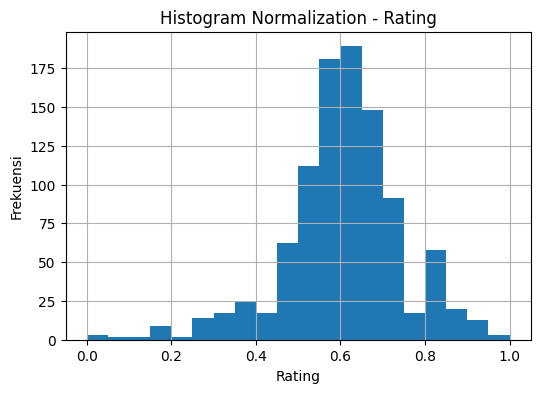

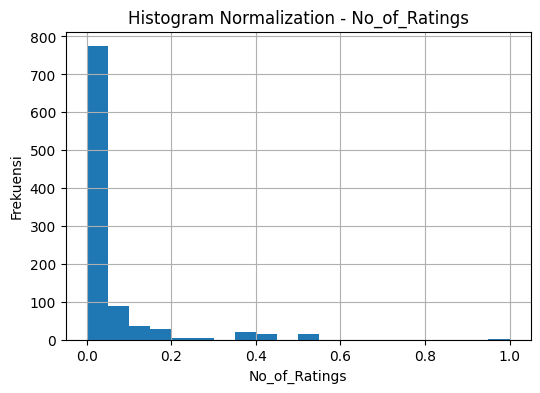

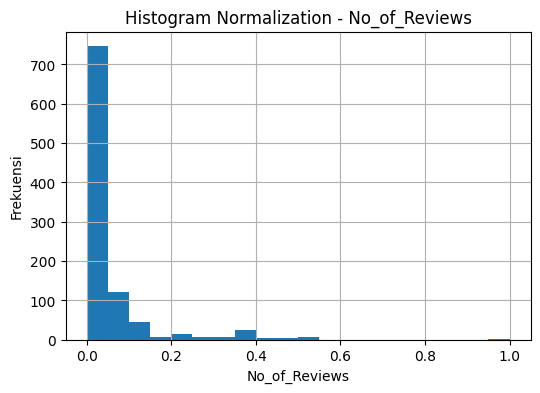

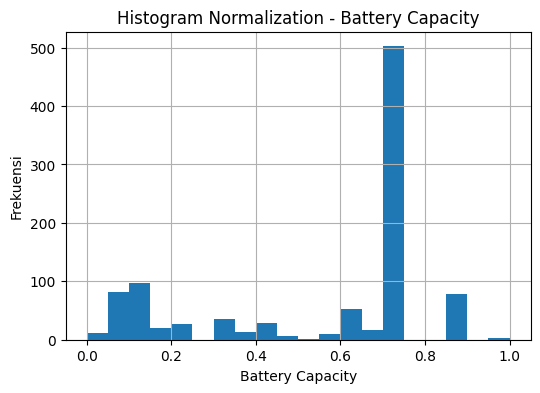

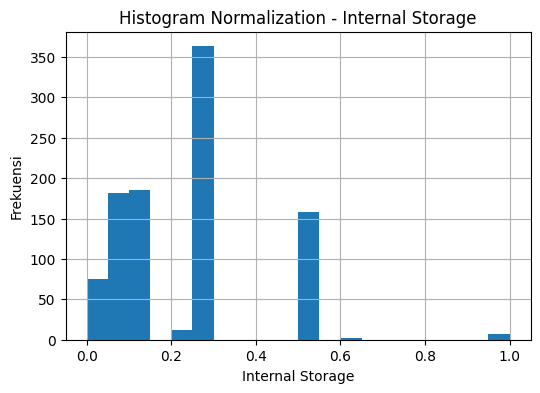

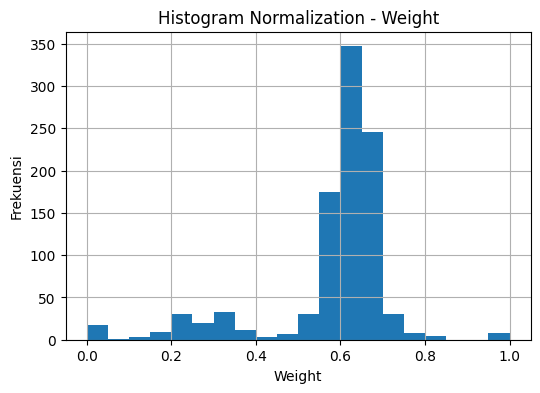

In [178]:
# Visualisasi data setelah Normalization
for col in main_features:
    plt.figure(figsize=(6, 4))
    plt.hist(df_normalized[col], bins=20)
    plt.title(f'Histogram Normalization - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.grid()
    plt.show()

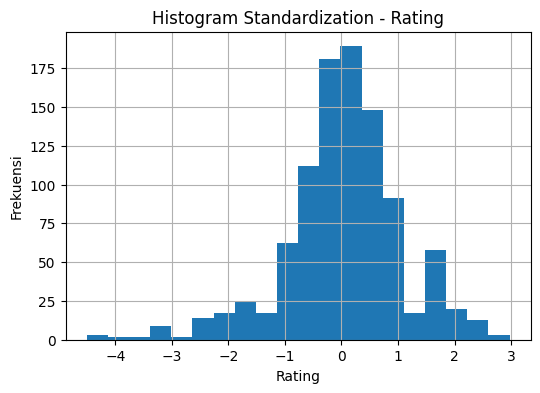

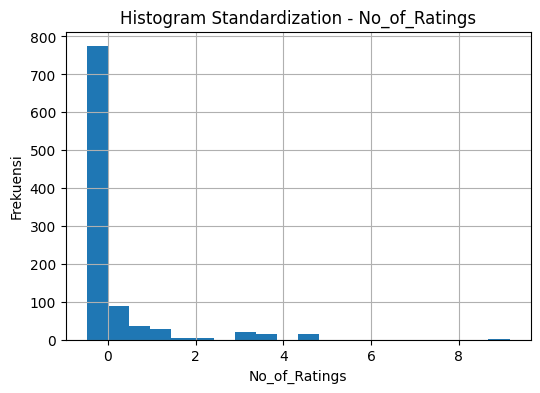

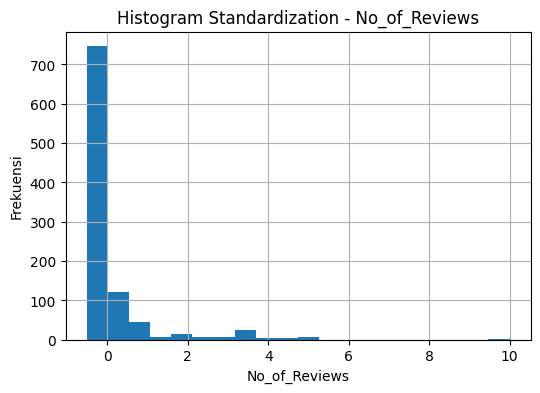

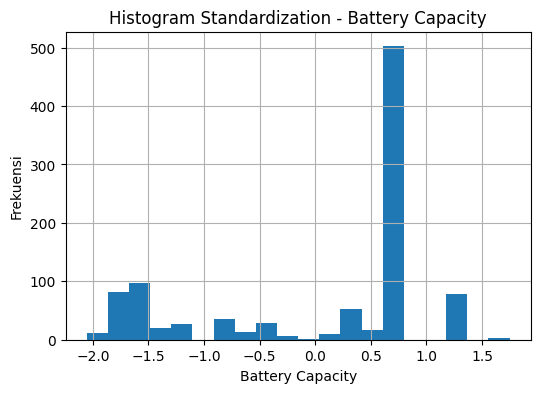

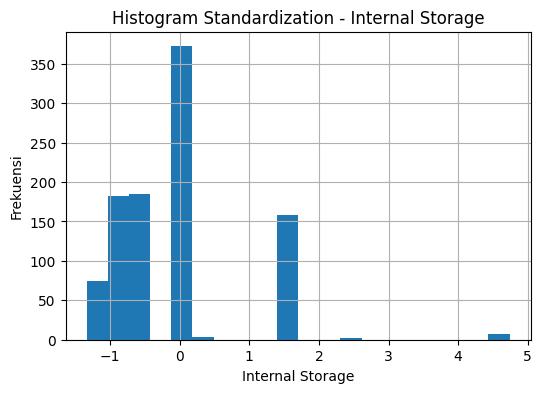

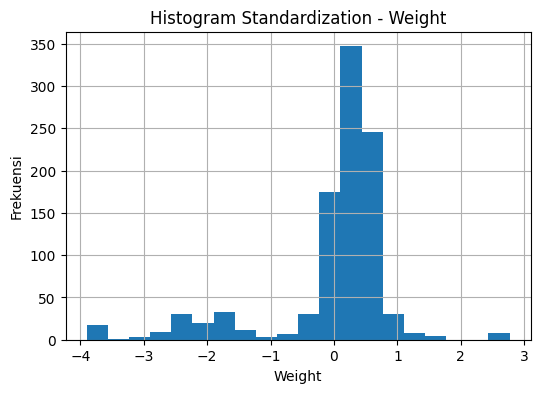

In [179]:
# Visualisasi data setelah Standardization
for col in main_features:
    plt.figure(figsize=(6, 4))
    plt.hist(df_standardized[col], bins=20)
    plt.title(f'Histogram Standardization - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.grid()
    plt.show()

## 10. Creating New Feature

Feature baru dibuat dengan memanfaatkan feature yang sudah ada.

In [180]:
df_feature = df_encoded.copy()

df_feature['Battery_per_Storage'] = df_feature['Battery Capacity'] / df_feature['Internal Storage'].replace(0, np.nan)
df_feature['Rating_per_Storage'] = df_feature['Rating'] / df_feature['Internal Storage'].replace(0, np.nan)

df_feature = df_feature.fillna(0)

df_feature[['Rating', 'Battery Capacity', 'Internal Storage', 
            'Battery_per_Storage', 'Rating_per_Storage']].head()

,Rating,Battery Capacity,Internal Storage,Battery_per_Storage,Rating_per_Storage
0,4.7,3240,128.0,25.3125,0.036719
1,4.1,5000,64.0,78.1250,0.064062
2,4.4,5000,128.0,39.0625,0.034375
3,4.3,5000,128.0,39.0625,0.033594
4,4.4,5000,128.0,39.0625,0.034375


In [181]:
# ==============================
# K-FOLD CROSS VALIDATION
# ==============================

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# df_feature = fitur
X = df_feature.copy()

# Price = target
y = df_imputation['Price'].reset_index(drop=True)

model = RandomForestRegressor(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R2 Score
scores_r2 = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("R2 tiap fold:", scores_r2)
print("Rata-rata R2:", scores_r2.mean())

# MAE
scores_mae = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
mae_asli = abs(scores_mae)

print("\nMAE tiap fold:", mae_asli)
print("Rata-rata MAE:", mae_asli.mean())

R2 tiap fold: [0.91502328 0.97380146 0.97043168 0.89326463 0.95043006]
Rata-rata R2: 0.9405902207485447

MAE tiap fold: [2596.49726613 1875.60727605 1413.09631895 3191.97429027 2439.64426271]
Rata-rata MAE: 2303.363882822513
